In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import iminuit
from iminuit import Minuit
from iminuit.cost import LeastSquares
from scipy.integrate import quad
import MMGPD

In [2]:
intval = pd.read_json("ExperimentalData.json")

In [3]:
gmp12 = intval["GMp12"]

In [4]:
gmp12.keys()

Index(['Q2', 'GE', 'dGE', 'Reference', 'GE/GD', 'd(GE/GD)', 'muGE/GM',
       'd(muGE/GM)', 'GEn', 'd(GEn)', 'GM/(muGD)', 'd(GM/(muGD))', 'epsilon',
       'SigR', 'd(SigR)', 'El', 'theta', 'SigTot', 'd(SigTot)'],
      dtype='object')

In [5]:
Q2 = gmp12["Q2"]
t = []
for items in Q2:
    t.append(-items)
t

[-1.577,
 -1.858,
 -4.543,
 -5.947,
 -6.993,
 -7.992,
 -9.002,
 -9.053,
 -9.807,
 -11.19,
 -12.07,
 -12.57,
 -15.76]

In [6]:
epsilon = gmp12["epsilon"]
epsilon

[0.7010000000000001,
 0.615,
 0.8260000000000001,
 0.709,
 0.599,
 0.47800000000000004,
 0.648,
 0.332,
 0.58,
 0.448,
 0.356,
 0.301,
 0.309]

In [7]:
MMGPD.getProfileFunctionParameters("HGAG23","E","Set11")("dv")

[0.743114214316566,
 -1.3248819398870835,
 3.78040091664933,
 0.6196494861575702,
 17.888673527013204,
 0.0]

In [8]:
H_aprime_uv=0.72839148754595151
H_aprime_dv=0.37973361822297491
H_aprime_sv=0.0000000000000000
H_B_uv=0.81860991615863821 
H_B_dv=1.6274794309491143
H_B_sv=0.0000000000000000
H_A_uv=0.99207454806962558   
H_A_dv=1.5608817800427934  
H_A_sv=0.0000000000000000
E_aprime_uv=0.90000000000000002
E_aprime_dv=0.61745548149770169 
E_aprime_sv=0.0000000000000000
E_B_uv=0.0000000000000000 
E_B_dv=0.0000000000000000 
E_B_sv=0.0000000000000000
E_A_uv=0.31758083222847555
E_A_dv=1.7185121894711912  
E_A_sv=0.0000000000000000
E_alpha_uv=0.70227034710861203
E_alpha_dv=0.81647398657747083
E_alpha_sv=0.0000000000000000
E_beta_uv=7.4215696141415366
E_beta_dv=6.8404845233133944 
E_beta_sv=0.0000000000000000
E_gamma_uv=4.3710919366571312 
E_gamma_dv=12.530808494164175      
E_gamma_sv=0.0000000000000000
Ks=0.0000000000000000

In [9]:
EMOBS = MMGPD.EMObservables("NNPDF40_nlo_as_01180", mu2 = 4, mp = 0.93827208816, mn = 0.9395654133, mup = 2.7928473446 , mun = -1.9130427)

LHAPDF 6.5.4 loading /opt/homebrew/anaconda3/envs/MMGPDs/share/LHAPDF/NNPDF40_nlo_as_01180/NNPDF40_nlo_as_01180_0000.dat
NNPDF40_nlo_as_01180 PDF set, member #0, version 1; LHAPDF ID = 331700
LHAPDF 6.5.4 loading all 101 PDFs in set NNPDF40_nlo_as_01180
NNPDF40_nlo_as_01180, version 1; 101 PDF members


/Users/apranikstar/Downloads/MMGPDs-main- My Analysis/src/emObservables.py:26: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  Nuv = quad(lambda x: self.__pdf.xPDFCentVal("uv", x, self.__mu2) / x, 1e-9, 1, limit=150)[0]


In [10]:
ID = 1
results = EMOBS.SigR( ID, t, epsilon, #mu2, 
           H_aprime_uv, H_aprime_dv, H_aprime_sv,
           H_B_uv, H_B_dv, H_B_sv,
           H_A_uv, H_A_dv, H_A_sv,
           E_aprime_uv, E_aprime_dv, E_aprime_sv,
           E_B_uv, E_B_dv, E_B_sv,
           E_A_uv, E_A_dv, E_A_sv,
           E_alpha_uv, E_alpha_dv, E_alpha_sv,
           E_beta_uv, E_beta_dv, E_beta_sv,
           E_gamma_uv, E_gamma_dv,E_gamma_sv,
           Ks,
           )

/Users/apranikstar/Downloads/MMGPDs-main- My Analysis/src/emObservables.py:209: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  return   (np.array([episilon[i] * np.power(quad(F1F2GE,1e-9,1, args=( 1,self.__m_p,t[i]), limit = 250)[0],2) for i in range(len(t))]))+np.array([ np.divide(-t[i] , 4 * np.power(self.__m_p,2)) * np.power(quad(F1F2GM,1e-9,1, args=( 1,t[i]), limit = 250)[0],2) for i in range(len(t))  ])


In [11]:
results

array([3.86004690e-02, 2.75186496e-02, 3.34563071e-03, 1.55012109e-03,
       9.54101080e-04, 6.32221018e-04, 4.36346312e-04, 4.26771447e-04,
       3.31410988e-04, 2.15330766e-04, 1.67454348e-04, 1.46154120e-04,
       6.73731237e-05])

In [12]:
gmp12["SigR"]

[0.042730000000000004,
 0.029830000000000002,
 0.003813,
 0.001805,
 0.001113,
 0.0007289,
 0.0005163,
 0.0004859,
 0.0003923,
 0.0002565,
 0.00019329999999999998,
 0.00016639999999999998,
 8.405e-05]

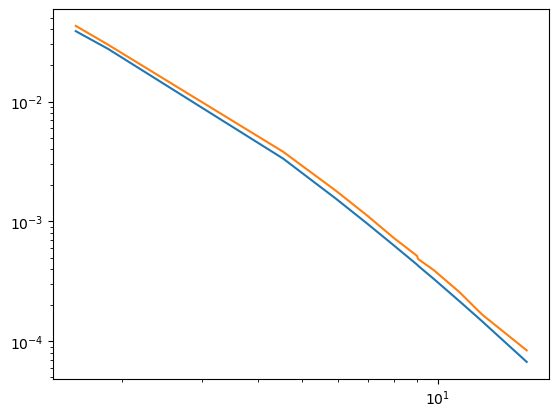

In [13]:
plt.plot(Q2 , results)
plt.plot(Q2, gmp12["SigR"])
plt.xscale("log")
plt.yscale("log")

In [14]:
El = 2143

In [15]:
intval["PRad_2.2"]

Q2              [0.0007, 0.000731, 0.000765, 0.000801, 0.00084...
GE                                                            NaN
dGE                                                           NaN
Reference                       [Nature 575 (2019) 7781, 147-150]
GE/GD                                                         NaN
d(GE/GD)                                                      NaN
muGE/GM                                                       NaN
d(muGE/GM)                                                    NaN
GEn                                                           NaN
d(GEn)                                                        NaN
GM/(muGD)                                                     NaN
d(GM/(muGD))                                                  NaN
epsilon                                                       NaN
SigR                                                          NaN
d(SigR)                                                       NaN
El        

In [16]:
Q2 = intval["PRad_2.2"]["Q2"]
t = []
for items in Q2:
    t.append(-items)
t

[-0.0007,
 -0.000731,
 -0.000765,
 -0.000801,
 -0.000841,
 -0.0008849999999999999,
 -0.0009339999999999999,
 -0.000987,
 -0.0010479999999999999,
 -0.001116,
 -0.001194,
 -0.001282,
 -0.001383,
 -0.001499,
 -0.0016339999999999998,
 -0.001789,
 -0.0019600000000000004,
 -0.002152,
 -0.0023769999999999998,
 -0.002653,
 -0.003002,
 -0.003463,
 -0.004089,
 -0.0050089999999999996,
 -0.006196999999999999,
 -0.007725999999999999,
 -0.009739,
 -0.012069,
 -0.014646,
 -0.017469,
 -0.020537,
 -0.023847999999999998,
 -0.027401,
 -0.031195999999999998,
 -0.035285,
 -0.040354,
 -0.046477,
 -0.058188]

In [17]:
theta = intval["PRad_2.2"]["theta"]
theta

[0.7075,
 0.723,
 0.7395,
 0.757,
 0.7755000000000001,
 0.7955,
 0.8170000000000001,
 0.84,
 0.8655,
 0.8935000000000001,
 0.924,
 0.9575,
 0.9945,
 1.0355,
 1.081,
 1.131,
 1.184,
 1.2405,
 1.304,
 1.3775,
 1.4655,
 1.574,
 1.7105000000000001,
 1.8935,
 2.1065,
 2.3525,
 2.642,
 2.942,
 3.242,
 3.542,
 3.842,
 4.142,
 4.442,
 4.742,
 5.046,
 5.4,
 5.8,
 6.5]

In [18]:
sigTott= EMOBS.SigTot( ID, t, #mu2, 
           H_aprime_uv, H_aprime_dv, H_aprime_sv,
           H_B_uv, H_B_dv, H_B_sv,
           H_A_uv, H_A_dv, H_A_sv,
           E_aprime_uv, E_aprime_dv, E_aprime_sv,
           E_B_uv, E_B_dv, E_B_sv,
           E_A_uv, E_A_dv, E_A_sv,
           E_alpha_uv, E_alpha_dv, E_alpha_sv,
           E_beta_uv, E_beta_dv, E_beta_sv,
           E_gamma_uv, E_gamma_dv,E_gamma_sv,
           Ks,
           theta,El  
           )


In [29]:
sigTOTPRAD = np.array(intval["PRad_2.2"]["SigTot"])

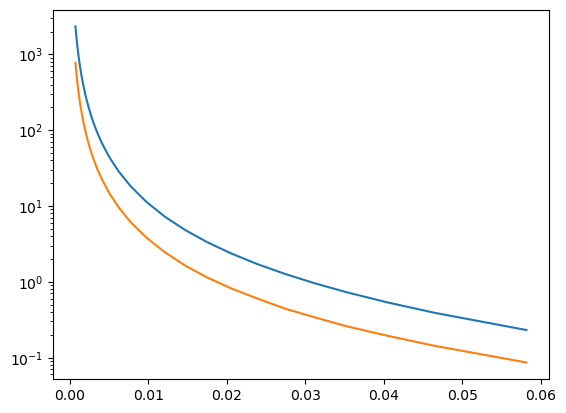

In [30]:
plt.plot(Q2 , sigTott)
plt.plot(Q2, sigTOTPRAD)
#plt.xscale("log")
plt.yscale("log")

In [21]:
sigTott

array([2.33336045e+03, 2.13917828e+03, 1.95412153e+03, 1.77917727e+03,
       1.61496361e+03, 1.45815989e+03, 1.31020581e+03, 1.17209060e+03,
       1.03953257e+03, 9.14821774e+02, 7.99478988e+02, 6.92934011e+02,
       5.95036172e+02, 5.05865930e+02, 4.25552370e+02, 3.54788187e+02,
       2.95074489e+02, 2.44574664e+02, 2.00011837e+02, 1.60333497e+02,
       1.24872730e+02, 9.35618804e+01, 6.68146645e+01, 4.42313165e+01,
       2.86569816e+01, 1.82433355e+01, 1.13217417e+01, 7.25517065e+00,
       4.84057093e+00, 3.33775790e+00, 2.36539932e+00, 1.71545937e+00,
       1.26885225e+00, 9.54584685e-01, 7.26299256e-01, 5.37180524e-01,
       3.89230953e-01, 2.30474431e-01])

In [22]:
intval["PRad_2.2"]

Q2              [0.0007, 0.000731, 0.000765, 0.000801, 0.00084...
GE                                                            NaN
dGE                                                           NaN
Reference                       [Nature 575 (2019) 7781, 147-150]
GE/GD                                                         NaN
d(GE/GD)                                                      NaN
muGE/GM                                                       NaN
d(muGE/GM)                                                    NaN
GEn                                                           NaN
d(GEn)                                                        NaN
GM/(muGD)                                                     NaN
d(GM/(muGD))                                                  NaN
epsilon                                                       NaN
SigR                                                          NaN
d(SigR)                                                       NaN
El        